# Player Retention Experiment Analysis

This notebook contains the reproducible Python analysis for the Cookie Cats A/B test. The stakeholder summary, business implications, and recommendations are documented in the project README.

**Decision:** Keep gate 30; do not ship gate 40.


## 1. Define metrics and decision criteria

- **Primary metric:** Seven-day retention
- **Secondary metric:** One-day retention
- **Exploratory metric:** Total game rounds
- **Treatment effect:** Gate 40 minus gate 30
- **Statistical standard:** Two-sided 5% significance level and 95% confidence intervals
- **Illustrative practical threshold:** 0.5 percentage points of seven-day retention


In [1]:
from pathlib import Path
import hashlib
import math
from urllib.request import urlopen

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

DATA_URL = "https://raw.githubusercontent.com/PN1019/MobileGameABTesting/main/cookie_cats_new.csv"
EXPECTED_SHA256 = "9f53027065840672e77303281289988371d4a6b67c7dcd3bd4e6306a2a263dc8"
LOCAL_DATA_PATH = Path("data/cookie_cats.csv")
ASSETS_DIR = Path("assets")

CONTROL = "gate_30"
TREATMENT = "gate_40"
Z975 = stats.norm.ppf(0.975)

LOCAL_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

if not LOCAL_DATA_PATH.exists():
    raw_data = urlopen(DATA_URL).read()
    LOCAL_DATA_PATH.write_bytes(raw_data)

data_sha256 = hashlib.sha256(LOCAL_DATA_PATH.read_bytes()).hexdigest()
if data_sha256 != EXPECTED_SHA256:
    raise ValueError(
        "Dataset checksum mismatch. Delete data/cookie_cats.csv and rerun the notebook."
    )

sns.set_theme(style="whitegrid", context="notebook")
pd.options.display.float_format = "{:.4f}".format


## 2. Load and validate the data


In [2]:
df = pd.read_csv(LOCAL_DATA_PATH)

required_columns = {
    "userid", "version", "sum_gamerounds", "retention_1", "retention_7"
}
retention_domains = {
    column: sorted(df[column].dropna().astype(int).unique().tolist())
    for column in ["retention_1", "retention_7"]
}

audit = {
    "rows": int(len(df)),
    "unique_players": int(df["userid"].nunique()),
    "duplicate_players": int(df["userid"].duplicated().sum()),
    "missing_values": int(df.isna().sum().sum()),
    "required_columns_present": required_columns.issubset(df.columns),
    "variants": sorted(df["version"].unique().tolist()),
    "retention_1_domain": retention_domains["retention_1"],
    "retention_7_domain": retention_domains["retention_7"],
    "negative_rounds": int((df["sum_gamerounds"] < 0).sum()),
    "minimum_rounds": int(df["sum_gamerounds"].min()),
    "maximum_rounds": int(df["sum_gamerounds"].max()),
    "sha256": data_sha256,
}

assert audit["rows"] == 90_189
assert audit["rows"] == audit["unique_players"]
assert audit["duplicate_players"] == 0
assert audit["missing_values"] == 0
assert audit["required_columns_present"]
assert audit["variants"] == [CONTROL, TREATMENT]
assert audit["retention_1_domain"] == [0, 1]
assert audit["retention_7_domain"] == [0, 1]
assert audit["negative_rounds"] == 0
assert audit["sha256"] == EXPECTED_SHA256

audit["status"] = "PASS"
pd.Series(audit, name="value").to_frame()


,value
rows,90189
unique_players,90189
duplicate_players,0
missing_values,0
required_columns_present,True
variants,"[gate_30, gate_40]"
retention_1_domain,"[0, 1]"
retention_7_domain,"[0, 1]"
negative_rounds,0
minimum_rounds,0


## 3. Check experiment allocation

The intended allocation ratio is not available. The 50/50 test is therefore a conditional quality check rather than proof of valid or invalid randomization.


In [3]:
counts = df["version"].value_counts().reindex([CONTROL, TREATMENT])
equal_allocation = stats.binomtest(
    int(counts[TREATMENT]), int(counts.sum()), p=0.5, alternative="two-sided"
)

allocation_df = df.copy()
allocation_df["enrollment_decile"] = pd.qcut(
    allocation_df["userid"], 10, labels=False, duplicates="drop"
)
allocation_table = pd.crosstab(
    allocation_df["enrollment_decile"], allocation_df["version"]
).reindex(columns=[CONTROL, TREATMENT])
chi2, decile_p, decile_df, _ = stats.chi2_contingency(allocation_table)
allocation_table["treatment_share"] = allocation_table[TREATMENT] / allocation_table.sum(axis=1)

assignment = {
    "control_n": int(counts[CONTROL]),
    "treatment_n": int(counts[TREATMENT]),
    "treatment_share": float(counts[TREATMENT] / counts.sum()),
    "equal_allocation_check_p_value": float(equal_allocation.pvalue),
    "allocation_by_id_decile_p_value": float(decile_p),
}

display(pd.Series(assignment, name="value").to_frame())
display(allocation_table)

,value
control_n,44700.0000
treatment_n,45489.0000
treatment_share,0.5044
equal_allocation_check_p_value,0.0087
allocation_by_id_decile_p_value,0.6051


version,gate_30,gate_40,treatment_share
enrollment_decile,,,
0,4474,4545,0.5039
1,4486,4533,0.5026
2,4507,4512,0.5003
3,4542,4477,0.4964
4,4391,4628,0.5131
5,4471,4547,0.5042
6,4487,4532,0.5025
7,4474,4545,0.5039
8,4450,4569,0.5066


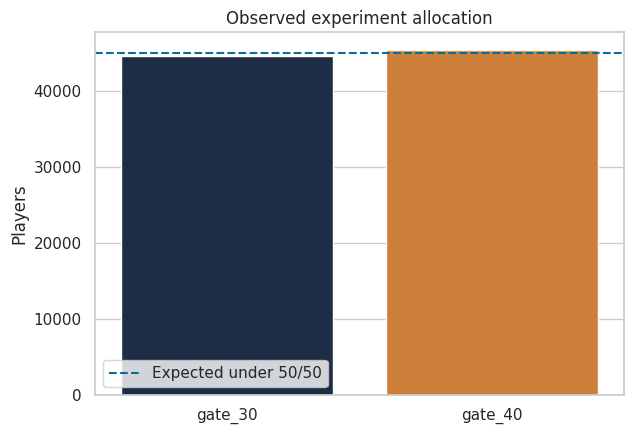

In [4]:
allocation_plot = counts.rename_axis("version").reset_index(name="players")
fig, ax = plt.subplots(figsize=(6.5, 4.5))
sns.barplot(
    data=allocation_plot, x="version", y="players", hue="version",
    palette=["#172B4D", "#E67E22"], legend=False, ax=ax
)
ax.axhline(len(df) / 2, color="#0B6E99", linestyle="--", label="Expected under 50/50")
ax.set(title="Observed experiment allocation", xlabel="", ylabel="Players")
ax.legend()
fig.tight_layout()
plt.show()

**Result:** Gate 40 contains 50.44% of players. This would be unusual under an exact 50/50 allocation (p=0.0087), while treatment share is stable across player-ID deciles (p=0.605). Confirm the configured ratio and exposure process before final sign-off.


## 4. Estimate retention effects


In [5]:
def difference_in_proportions(data, outcome):
    control = data.loc[data["version"] == CONTROL, outcome].astype(int)
    treatment = data.loc[data["version"] == TREATMENT, outcome].astype(int)
    nc, nt = len(control), len(treatment)
    xc, xt = int(control.sum()), int(treatment.sum())
    pc, pt = xc / nc, xt / nt
    effect = pt - pc

    se_effect = math.sqrt(pc * (1 - pc) / nc + pt * (1 - pt) / nt)
    ci_low = effect - Z975 * se_effect
    ci_high = effect + Z975 * se_effect

    pooled = (xc + xt) / (nc + nt)
    se_null = math.sqrt(pooled * (1 - pooled) * (1 / nc + 1 / nt))
    z_stat = effect / se_null
    p_value = 2 * stats.norm.sf(abs(z_stat))

    return {
        "metric": outcome,
        "control_n": nc,
        "treatment_n": nt,
        "control_successes": xc,
        "treatment_successes": xt,
        "control_rate": pc,
        "treatment_rate": pt,
        "absolute_effect": effect,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "relative_effect": effect / pc,
        "z_statistic": z_stat,
        "p_value": p_value,
        "retained_players_per_100k": effect * 100_000,
        "retained_players_per_100k_ci_low": ci_low * 100_000,
        "retained_players_per_100k_ci_high": ci_high * 100_000,
        "standard_error": se_effect,
    }


effects = pd.DataFrame([
    difference_in_proportions(df, "retention_1"),
    difference_in_proportions(df, "retention_7"),
])

display_table = effects[[
    "metric", "control_rate", "treatment_rate", "absolute_effect",
    "ci_low", "ci_high", "relative_effect", "p_value"
]].copy()
for col in ["control_rate", "treatment_rate", "absolute_effect", "ci_low", "ci_high", "relative_effect"]:
    display_table[col] = display_table[col] * 100
display_table

,metric,control_rate,treatment_rate,absolute_effect,ci_low,ci_high,relative_effect,p_value
0,retention_1,44.8188,44.2283,-0.5905,-1.2392,0.0582,-1.3176,0.0744
1,retention_7,19.0201,18.2000,-0.8201,-1.3282,-0.3121,-4.3119,0.0016


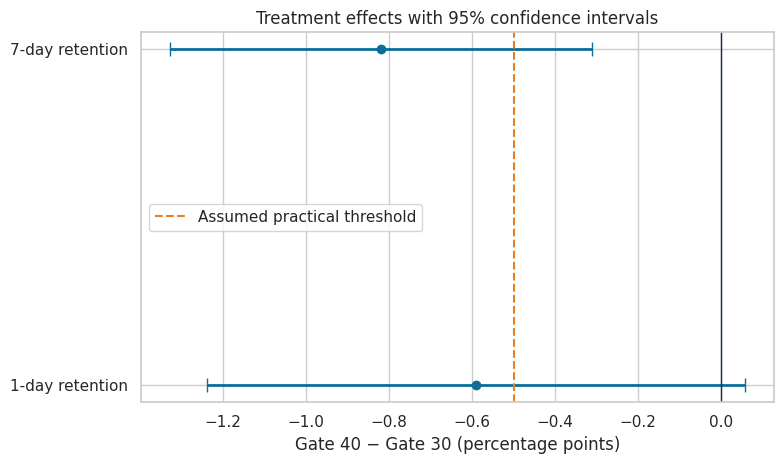

In [6]:
plot = effects.copy()
plot["effect_pp"] = plot["absolute_effect"] * 100
plot["low_pp"] = plot["ci_low"] * 100
plot["high_pp"] = plot["ci_high"] * 100
labels = {"retention_1": "1-day retention", "retention_7": "7-day retention"}

fig, ax = plt.subplots(figsize=(8, 4.8))
y = np.arange(len(plot))
ax.errorbar(
    plot["effect_pp"], y,
    xerr=[plot["effect_pp"] - plot["low_pp"], plot["high_pp"] - plot["effect_pp"]],
    fmt="o", color="#0B6E99", capsize=5, linewidth=2
)
ax.axvline(0, color="#172B4D", linewidth=1)
ax.axvline(-0.5, color="#E67E22", linestyle="--", label="Assumed practical threshold")
ax.set_yticks(y, [labels[x] for x in plot["metric"]])
ax.set(
    xlabel="Gate 40 − Gate 30 (percentage points)",
    title="Treatment effects with 95% confidence intervals"
)
ax.legend()
fig.tight_layout()
fig.savefig(ASSETS_DIR / "retention_effects.png", dpi=180, bbox_inches="tight")
plt.show()


**Result:** Seven-day retention declined by 0.82 percentage points (95% CI: −1.33 to −0.31, p=0.0016). One-day retention declined by 0.59 points, but its confidence interval includes zero.


## 5. Estimate sample sensitivity


In [7]:
primary = effects.set_index("metric").loc["retention_7"]
average_rate = (primary["control_rate"] + primary["treatment_rate"]) / 2
harmonic_n = 2 / (1 / primary["control_n"] + 1 / primary["treatment_n"])
se_equal = math.sqrt(2 * average_rate * (1 - average_rate) / harmonic_n)
mde = (stats.norm.ppf(0.975) + stats.norm.ppf(0.80)) * se_equal

power_summary = pd.Series({
    "two_sided_alpha": 0.05,
    "target_power": 0.80,
    "approximate_mde_percentage_points": mde * 100,
    "observed_effect_percentage_points": primary["absolute_effect"] * 100,
})
power_summary.to_frame("value")

,value
two_sided_alpha,0.0500
target_power,0.8000
approximate_mde_percentage_points,0.7262
observed_effect_percentage_points,-0.8201


**Result:** The approximate minimum detectable effect is 0.73 percentage points at 80% power and a two-sided 5% significance level.


## 6. Analyze game-round engagement

Game rounds are highly skewed and measured after assignment. The analysis uses robust comparisons and does not use rounds to create treatment-effect subgroups.


In [8]:
engagement_rows = []
for version, group in df.groupby("version", observed=True):
    rounds = group["sum_gamerounds"].to_numpy()
    engagement_rows.append({
        "version": version,
        "players": len(rounds),
        "mean": rounds.mean(),
        "median": np.median(rounds),
        "p90": np.quantile(rounds, 0.90),
        "p95": np.quantile(rounds, 0.95),
        "p99": np.quantile(rounds, 0.99),
        "zero_round_share": np.mean(rounds == 0),
        "maximum": rounds.max(),
    })

engagement_summary = pd.DataFrame(engagement_rows).sort_values("version")

control_rounds = df.loc[df["version"] == CONTROL, "sum_gamerounds"].to_numpy()
treatment_rounds = df.loc[df["version"] == TREATMENT, "sum_gamerounds"].to_numpy()
rank_test = stats.mannwhitneyu(treatment_rounds, control_rounds, alternative="two-sided")
rank_biserial = 2 * rank_test.statistic / (len(treatment_rounds) * len(control_rounds)) - 1

winsor_cap = df["sum_gamerounds"].quantile(0.995)
control_w = np.minimum(control_rounds, winsor_cap)
treatment_w = np.minimum(treatment_rounds, winsor_cap)
winsor_effect = treatment_w.mean() - control_w.mean()
winsor_se = math.sqrt(treatment_w.var(ddof=1) / len(treatment_w) + control_w.var(ddof=1) / len(control_w))

engagement_result = pd.Series({
    "mann_whitney_p_value": rank_test.pvalue,
    "rank_biserial_effect": rank_biserial,
    "winsor_cap": winsor_cap,
    "winsorized_mean_effect": winsor_effect,
    "winsorized_ci_low": winsor_effect - Z975 * winsor_se,
    "winsorized_ci_high": winsor_effect + Z975 * winsor_se,
})

display(engagement_summary)
display(engagement_result.to_frame("value"))

,version,players,mean,median,p90,p95,p99,zero_round_share,maximum
0,gate_30,44700,52.4563,17.0000,135.0000,222.0000,493.0000,0.0433,49854
1,gate_40,45489,51.2988,16.0000,134.0000,220.0000,492.1200,0.0452,2640


,value
mann_whitney_p_value,0.0502
rank_biserial_effect,-0.0075
winsor_cap,623.0600
winsorized_mean_effect,-0.2600
winsorized_ci_low,-1.4296
winsorized_ci_high,0.9095


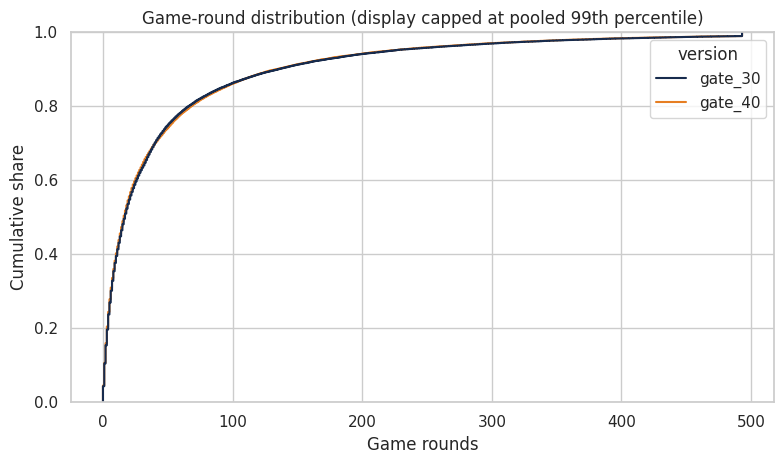

In [9]:
display_cap = df["sum_gamerounds"].quantile(0.99)
ecdf_data = df.assign(rounds_display=df["sum_gamerounds"].clip(upper=display_cap))
fig, ax = plt.subplots(figsize=(8, 4.8))
sns.ecdfplot(
    data=ecdf_data, x="rounds_display", hue="version",
    palette=["#172B4D", "#E67E22"], ax=ax
)
ax.set(
    title="Game-round distribution (display capped at pooled 99th percentile)",
    xlabel="Game rounds", ylabel="Cumulative share"
)
fig.tight_layout()
plt.show()

**Result:** Median game rounds were 17 for gate 30 and 16 for gate 40. The winsorized difference was −0.26 rounds (95% CI: −1.43 to +0.91), with a negligible rank-biserial effect.


## 7. Final result

**Keep gate 30; do not ship gate 40.** Gate 40 did not demonstrate an improvement and instead reduced seven-day retention without producing an engagement benefit.

Confirm the intended assignment ratio and exposure process before final sign-off. If that review identifies an invalid assignment or exposure process, rerun the experiment before making a permanent product decision.


## 8. Data limitations

The public dataset does not include experiment dates, the original analysis plan, allocation configuration, exposure rules, detailed metric definitions, pre-treatment player attributes, or monetization outcomes.


In [10]:
# Collect the core results in one object for easy review.
experiment_summary = {
    "decision": "KEEP GATE 30; DO NOT SHIP GATE 40",
    "audit": audit,
    "assignment": assignment,
    "retention_effects": effects.to_dict(orient="records"),
    "prospective_sensitivity": power_summary.to_dict(),
    "engagement": engagement_result.to_dict(),
}
print("Decision: KEEP GATE 30; DO NOT SHIP GATE 40")
print(f"Seven-day effect: {primary['absolute_effect']*100:.2f} percentage points")
print(f"95% CI: [{primary['ci_low']*100:.2f}, {primary['ci_high']*100:.2f}] percentage points")
print("All notebook assertions completed successfully.")

Decision: KEEP GATE 30; DO NOT SHIP GATE 40
Seven-day effect: -0.82 percentage points
95% CI: [-1.33, -0.31] percentage points
All notebook assertions completed successfully.
